In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np




In [10]:
usage_df = pl.read_parquet("/Users/pratyaksh/UTA/Sem4/dgup/data/silver/uta_gas_usage.parquet")

In [ ]:
usage_df = pl.read_parquet("/Users/pratyaksh/UTA/Sem4/dgup/data/silver/uta_gas_usage.parquet")
usage_df.select(pl.col("*").is_null().sum())
# fill nulls with 0
usage_df = usage_df.fill_null(0)


all_preds = pd.DataFrame()
#total_usage = usage_df.select(pl.col("usage").sum())
total_df = usage_df.with_columns(
    pl.sum_horizontal(["Usage - 1", "Usage - 2", "Usage - 2_1"]).alias("total_usage")
)
total_df = total_df.select(["Date", "total_usage"])
total_df = total_df.to_pandas()

In [ ]:
usage_cols = ["Usage - 1", "Usage - 2", "Usage - 2_1"]

for x in usage_cols:

    # Select column
    df = usage_df.select(["Date", x])
    df = df.rename({"Date": "ds", x: "y"})
    df = df.to_pandas()
    df['ds'] = pd.to_datetime(df['ds'])
    df = df.dropna()

    # Train Prophet
    model = Prophet()
    model.fit(df)

    # Create future until 2024-11-30
    last_train_date = df['ds'].max()
    target_date = pd.to_datetime("2024-11-30")
    periods = (target_date - last_t rain_date).days

    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    # Keep only 2024
    forecast_2024 = forecast[forecast['ds'].dt.year == 2024][['ds', 'yhat']]

    # Rename yhat dynamically
    forecast_2024 = forecast_2024.rename(columns={
        'yhat': f'yhat_{x}'
    })

    # Merge predictions
    if all_preds.empty:
        all_preds = forecast_2024
    else:
        all_preds = all_preds.merge(forecast_2024, on='ds', how='inner')


11:51:01 - cmdstanpy - INFO - Chain [1] start processing
11:51:02 - cmdstanpy - INFO - Chain [1] done processing
11:51:02 - cmdstanpy - INFO - Chain [1] start processing
11:51:02 - cmdstanpy - INFO - Chain [1] done processing
11:51:02 - cmdstanpy - INFO - Chain [1] start processing
11:51:03 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
all_preds['total_pred'] = (
    all_preds['yhat_Usage - 1'] +
    all_preds['yhat_Usage - 2'] +
    all_preds['yhat_Usage - 2_1']
)
actual_total = total_df.copy()
actual_total['Date'] = pd.to_datetime(actual_total['Date'])

actual_total = actual_total.rename(columns={
    'Date': 'ds'
})

actual_total_2024 = actual_total[actual_total['ds'].dt.year == 2024]


In [ ]:
final_compare = actual_total_2024.merge(
    all_preds[['ds', 'total_pred']],
    on='ds',
    how='inner'
)


mae_total = mean_absolute_error(
    final_compare['total_usage'],
    final_compare['total_pred']
)

mse_total = mean_squared_error(
    final_compare['total_usage'],
    final_compare['total_pred']
)

rmse_total = np.sqrt(mse_total)

print("TOTAL MAE  :", mae_total)
print("TOTAL RMSE :", rmse_total)


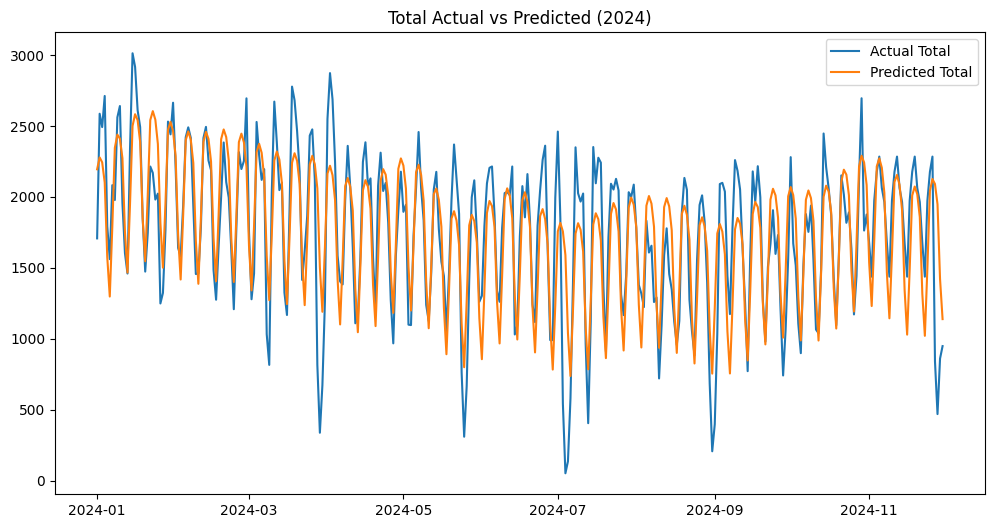

In [ ]:


plt.figure(figsize=(12,6))
plt.plot(final_compare['ds'], final_compare['total_usage'], label='Actual Total')
plt.plot(final_compare['ds'], final_compare['total_pred'], label='Predicted Total')

plt.legend()
plt.title("Total Actual vs Predicted (2024)")
plt.show()
